# STANCE: Spatial Transcriptomics Analysis via Nuclear Norm Completion

**Objective:** Formulate missing data recovery in Spatial Transcriptomics (ST) as a strictly convex matrix completion problem.

This notebook provides a comprehensive end-to-end analytical pipeline evaluating standard Nuclear Norm Completion (**FIST**) against Graph-Regularized Matrix Completion (**STANCE**). It executes on both synthetic topological arrays and real 10x Genomics Visium datasets.

In [ ]:
!pip install -q scanpy squidpy scikit-learn pandas matplotlib seaborn

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.utils.extmath import randomized_svd
from scipy.stats import pearsonr
import scipy.sparse as sp
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
def build_graph_laplacian(coords, k_neighbors=6):
    """Constructs the spatial topology matrix (Graph Laplacian)."""
    nbrs = NearestNeighbors(n_neighbors=k_neighbors + 1).fit(coords)
    _, indices = nbrs.kneighbors(coords)
    n = coords.shape[0]
    W = np.zeros((n, n))
    for i in range(n):
        for j in range(1, k_neighbors + 1):
            neighbor_idx = indices[i, j]
            W[i, neighbor_idx] = 1.0
            W[neighbor_idx, i] = 1.0
    D = np.diag(W.sum(axis=1))
    return D - W

def optimize_matrix(X_obs, mask, L=None, beta=0.0, alpha=2.5, max_iter=150, X_true=None, hidden_mask=None):
    """FISTA-based Matrix Completion Solver."""
    Y = np.copy(X_obs)
    lr = 0.05
    metrics = {'rmse': [], 'rank': [], 'loss': []}

    L_dense = L.toarray() if sp.issparse(L) else L if L is not None else None

    for i in range(max_iter):
        # 1. Gradient Step
        grad = mask * (Y - X_obs)
        if L_dense is not None and beta > 0:
            grad += beta * (L_dense @ Y) # Spatial Regularization Penalty

        Y_step = Y - lr * grad

        # 2. Proximal Step: Singular Value Thresholding (SVT)
        n_comps = min(15, min(Y.shape)-1)
        U, S, Vt = randomized_svd(Y_step, n_components=n_comps, random_state=42)
        S_thresh = np.maximum(S - (lr * alpha), 0)
        Y = np.maximum(U @ np.diag(S_thresh) @ Vt, 0) # Non-negativity constraint

        # 3. Analytical Tracking
        if X_true is not None and hidden_mask is not None:
            rmse = np.sqrt(np.mean((X_true[hidden_mask] - Y[hidden_mask])**2))
            metrics['rmse'].append(rmse)

        metrics['rank'].append(np.sum(S_thresh > 1e-3))
        fidelity = 0.5 * np.sum(((Y - X_obs) * mask)**2)
        metrics['loss'].append(fidelity + alpha * np.sum(S_thresh))

        # Live Tracker
        if (i + 1) % 50 == 0 or i == 0:
            print(f"    -> Iteration {i+1:3d}/{max_iter} | Loss: {metrics['loss'][-1]:.2f} | Rank: {metrics['rank'][-1]}")

    return Y, metrics

In [ ]:
def run_and_compare(X_true, X_obs, mask, hidden_mask, coords, L, dataset_name=""):
    print(f"\n{'='*50}")
    print(f" BENCHMARKING: {dataset_name}")
    print(f"{'='*50}")

    # --- 1. Execute FIST (Baseline) ---
    print("\n[1/2] Executing FIST (Nuclear Norm Only | beta=0.0)...")
    Y_fist, met_fist = optimize_matrix(X_obs, mask, L=None, beta=0.0, alpha=2.5, max_iter=150, X_true=X_true, hidden_mask=hidden_mask)

    # --- 2. Execute STANCE (Spatial Graph) ---
    print("\n[2/2] Executing STANCE (Nuclear Norm + Graph Laplacian | beta=0.6)...")
    Y_stance, met_stance = optimize_matrix(X_obs, mask, L=L, beta=0.6, alpha=2.5, max_iter=150, X_true=X_true, hidden_mask=hidden_mask)

    # --- 3. Compute Metrics ---
    def get_metrics(Y_pred, name):
        rmse = np.sqrt(np.mean((X_true[hidden_mask] - Y_pred[hidden_mask])**2))
        r_val, _ = pearsonr(X_true[hidden_mask], Y_pred[hidden_mask])
        return {'Algorithm': name, 'RMSE (Hidden)': rmse, 'Pearson r': r_val, 'Final Rank': np.linalg.matrix_rank(Y_pred, tol=1e-3)}

    df = pd.DataFrame([get_metrics(Y_fist, 'FIST'), get_metrics(Y_stance, 'STANCE')])
    display(df.style.set_caption(f"{dataset_name} Results").highlight_min(subset=['RMSE (Hidden)'], color='lightgreen').highlight_max(subset=['Pearson r'], color='lightgreen'))

    # --- 4. Plot 6-Panel Dashboard ---
    fig = plt.figure(figsize=(20, 10))
    from matplotlib.gridspec import GridSpec
    gs = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.25)

    ax_true = fig.add_subplot(gs[0, 0])
    ax_fist = fig.add_subplot(gs[0, 1])
    ax_stance = fig.add_subplot(gs[0, 2])
    ax_obs = fig.add_subplot(gs[1, 0])
    ax_rmse = fig.add_subplot(gs[1, 1])
    ax_rank = fig.add_subplot(gs[1, 2])

    gene_idx = 0
    # Row 1: Tissue Maps
    sc0 = ax_true.scatter(coords[:, 0], coords[:, 1], c=X_true[:, gene_idx], cmap='magma', s=25)
    ax_true.set_title('[A] Ground Truth Expression', fontweight='bold')

    sc1 = ax_fist.scatter(coords[:, 0], coords[:, 1], c=Y_fist[:, gene_idx], cmap='magma', s=25)
    ax_fist.set_title(f"[B] FIST Prediction (RMSE: {df.iloc[0]['RMSE (Hidden)']:.3f})", fontweight='bold')

    sc2 = ax_stance.scatter(coords[:, 0], coords[:, 1], c=Y_stance[:, gene_idx], cmap='magma', s=25)
    ax_stance.set_title(f"[C] STANCE Prediction (RMSE: {df.iloc[1]['RMSE (Hidden)']:.3f})", fontweight='bold')

    # Row 2: Input & Convergence
    sc3 = ax_obs.scatter(coords[:, 0], coords[:, 1], c=X_obs[:, gene_idx], cmap='magma', s=25)
    ax_obs.set_title('[D] Raw Input (With Masked/Missing Dropouts)', fontweight='bold')

    for ax in [ax_true, ax_fist, ax_stance, ax_obs]:
        ax.invert_yaxis()
        ax.set_aspect('equal')
        ax.axis('off')
        plt.colorbar(sc0, ax=ax, fraction=0.046, pad=0.04)

    # RMSE Plot
    ax_rmse.plot(met_fist['rmse'], label='FIST (No Graph)', lw=3, linestyle='--', color='#EE6677')
    ax_rmse.plot(met_stance['rmse'], label='STANCE (Spatial Graph)', lw=2, color='#4477AA')
    ax_rmse.set_title('[E] RMSE Convergence', fontweight='bold')
    ax_rmse.set_xlabel('Iteration'); ax_rmse.set_ylabel('RMSE')
    ax_rmse.legend()

    # Rank Plot (Thick transparent line for FIST to show overlap)
    ax_rank.plot(met_fist['rank'], label='FIST Rank', lw=8, alpha=0.3, color='#EE6677')
    ax_rank.plot(met_stance['rank'], label='STANCE Rank', lw=2, color='#4477AA')
    ax_rank.set_title('[F] Effective Rank Evolution', fontweight='bold')
    ax_rank.set_xlabel('Iteration'); ax_rank.set_ylabel('Singular Values > 1e-3')
    ax_rank.legend()

    fig.suptitle(f"Comparison Dashboard: {dataset_name}", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


 BENCHMARKING: Small Generative (Synthetic) ST Data

[1/2] Executing FIST (Nuclear Norm Only | beta=0.0)...
    -> Iteration   1/150 | Loss: 3052.25 | Rank: 15
    -> Iteration  50/150 | Loss: 1945.52 | Rank: 15
    -> Iteration 100/150 | Loss: 1574.33 | Rank: 15
    -> Iteration 150/150 | Loss: 1437.23 | Rank: 15

[2/2] Executing STANCE (Nuclear Norm + Graph Laplacian | beta=0.6)...
    -> Iteration   1/150 | Loss: 3254.77 | Rank: 15
    -> Iteration  50/150 | Loss: 3124.28 | Rank: 15
    -> Iteration 100/150 | Loss: 2327.15 | Rank: 15
    -> Iteration 150/150 | Loss: 1908.64 | Rank: 15


,Algorithm,RMSE (Hidden),Pearson r,Final Rank
0,FIST,1.163216,0.587722,66
1,STANCE,0.830473,0.888996,15


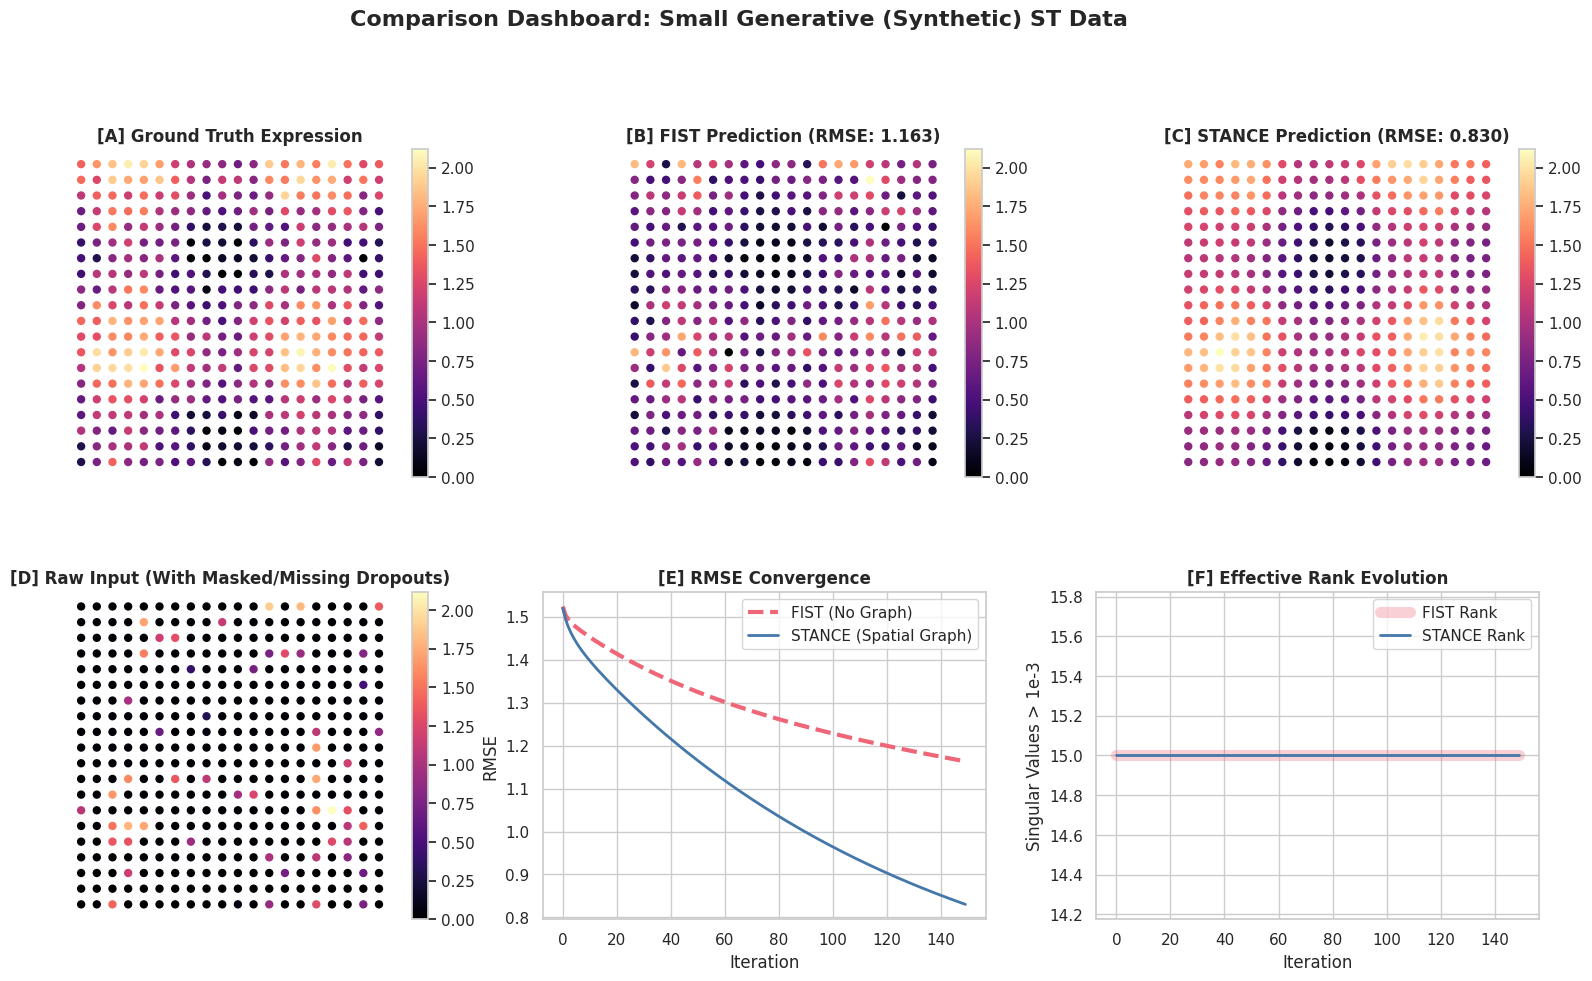

In [ ]:
# Generate Synthetic Data
n_spots, n_genes = 400, 100
grid_size = int(np.sqrt(n_spots))
x, y = np.meshgrid(np.linspace(0, 10, grid_size), np.linspace(0, 10, grid_size))
coords_syn = np.column_stack((x.flatten(), y.flatten()))

np.random.seed(42)
manifold = np.sin(coords_syn[:, 0]) + np.cos(coords_syn[:, 1])
manifold = (manifold - manifold.min()) / (manifold.max() - manifold.min())
X_true_syn = np.outer(manifold, np.random.rand(n_genes) * 5) + np.random.normal(0, 0.2, (n_spots, n_genes))
X_true_syn = np.maximum(X_true_syn, 0)

# Apply Dropout & Masks
base_mask = np.random.rand(n_spots, n_genes) > 0.80
hidden_mask_syn = base_mask & (np.random.rand(*X_true_syn.shape) < 0.30)
observed_mask_syn = base_mask & ~hidden_mask_syn

X_obs_syn = X_true_syn * observed_mask_syn
L_syn = build_graph_laplacian(coords_syn)

# Run Unified Benchmark
run_and_compare(X_true_syn, X_obs_syn, observed_mask_syn, hidden_mask_syn, coords_syn, L_syn, dataset_name="Small Generative (Synthetic) ST Data")


 BENCHMARKING: Real ST Data (10x Genomics Visium)

[1/2] Executing FIST (Nuclear Norm Only | beta=0.0)...
    -> Iteration   1/150 | Loss: 13655.57 | Rank: 15
    -> Iteration  50/150 | Loss: 6509.29 | Rank: 15
    -> Iteration 100/150 | Loss: 4924.91 | Rank: 15
    -> Iteration 150/150 | Loss: 4320.09 | Rank: 15

[2/2] Executing STANCE (Nuclear Norm + Graph Laplacian | beta=0.6)...
    -> Iteration   1/150 | Loss: 13510.53 | Rank: 15
    -> Iteration  50/150 | Loss: 7130.77 | Rank: 15
    -> Iteration 100/150 | Loss: 5674.18 | Rank: 15
    -> Iteration 150/150 | Loss: 5217.98 | Rank: 15


,Algorithm,RMSE (Hidden),Pearson r,Final Rank
0,FIST,0.350336,0.604127,102
1,STANCE,0.238749,0.794973,35


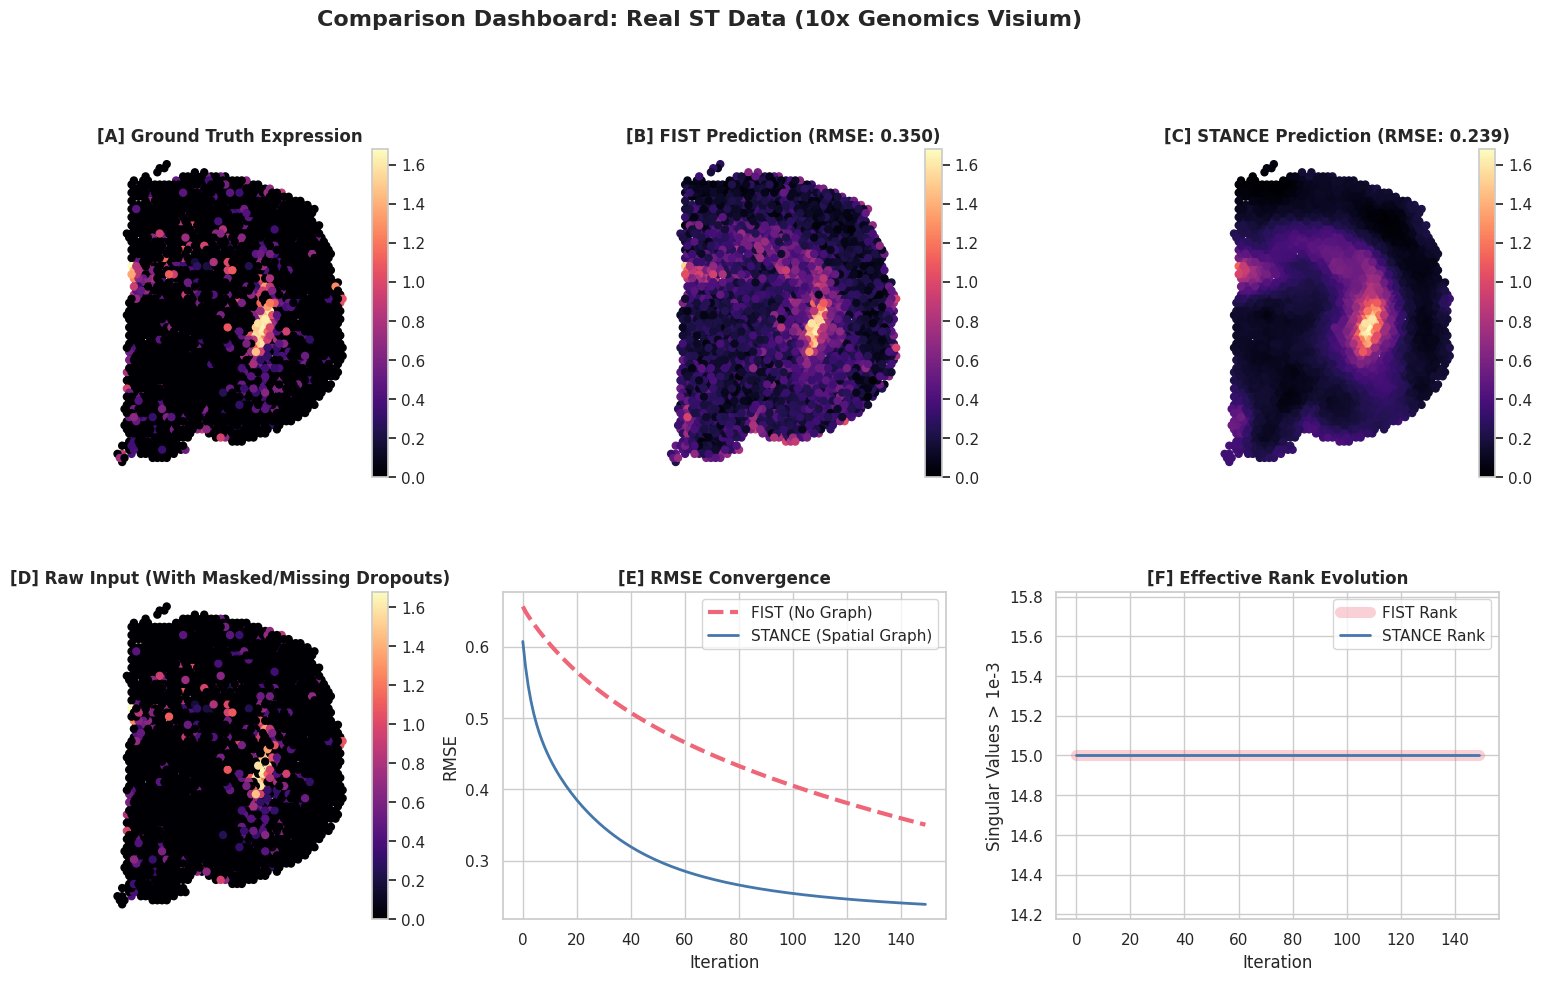

In [ ]:
print('Downloading 10x Visium Database (This takes 1-2 minutes)...')
adata = sq.datasets.visium_hne_adata()
sc.pp.filter_cells(adata, min_counts=500)
sc.pp.filter_genes(adata, min_cells=10)
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=200, flavor='seurat')
adata = adata[:, adata.var['highly_variable']]

coords_real = adata.obsm['spatial']
X_real = adata.X.toarray() if sp.issparse(adata.X) else adata.X

np.random.seed(42)
non_zero_mask_real = (X_real > 0)
hidden_mask_real = non_zero_mask_real & (np.random.rand(*X_real.shape) < 0.30)
observed_mask_real = non_zero_mask_real & ~hidden_mask_real

X_obs_real = X_real * observed_mask_real
L_real = build_graph_laplacian(coords_real)

# Run Unified Benchmark
run_and_compare(X_real, X_obs_real, observed_mask_real, hidden_mask_real, coords_real, L_real, dataset_name="Real ST Data (10x Genomics Visium)")